# Traffic Control System

# CODE 1

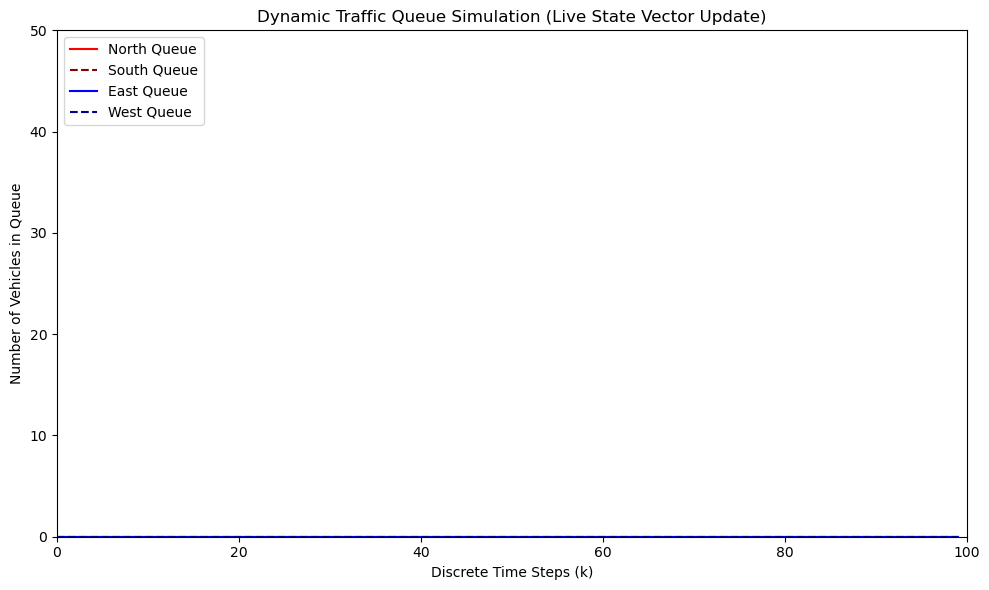

In [1]:
#!/usr/bin/env python3
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# 1. INITIALIZE MATRICES & VECTORS
# X: Queue state vector [North, South, East, West]
X = np.array([0, 0, 0, 0], dtype=float)

# C_max: Absolute physical capacity vector per lane per tick
C_max = np.array([8, 8, 8, 8], dtype=float)

# Lambda rates for Poisson distribution (Average arrivals per tick)
# Assuming N/S is a heavier traffic artery than E/W
lambda_rates = [4.0, 4.2, 2.5, 2.0]

# 2. VISUALIZATION SETUP
history_length = 100
time_steps = np.arange(history_length)
# History matrix to store the last 100 ticks for [N, S, E, W]
history_X = np.zeros((4, history_length))

fig, ax = plt.subplots(figsize=(10, 6))
lines = [
    ax.plot(time_steps, history_X[0], label='North Queue', color='red')[0],
    ax.plot(time_steps, history_X[1], label='South Queue', color='darkred', linestyle='--')[0],
    ax.plot(time_steps, history_X[2], label='East Queue', color='blue')[0],
    ax.plot(time_steps, history_X[3], label='West Queue', color='darkblue', linestyle='--')[0]
]

ax.set_ylim(0, 50)
ax.set_xlim(0, history_length)
ax.set_ylabel('Number of Vehicles in Queue')
ax.set_xlabel('Discrete Time Steps (k)')
ax.set_title('Dynamic Traffic Queue Simulation (Live State Vector Update)')
ax.legend(loc='upper left')

# 3. DYNAMIC STATE UPDATE FUNCTION
def update_state(frame):
    global X, history_X
    
    # Generate exogenous arrivals A(k) using Poisson distribution
    A = np.random.poisson(lambda_rates)
    
    # Phase Selection Logic: Switch lights every 10 ticks
    # Phase 0: North/South Green. Phase 1: East/West Green.
    phase = (frame // 10) % 2
    
    if phase == 0:
        # G(k) = diag(1, 1, 0, 0)
        G = np.diag([1, 1, 0, 0])
        ax.set_title('Phase: NORTH / SOUTH GREEN')
    else:
        # G(k) = diag(0, 0, 1, 1)
        G = np.diag([0, 0, 1, 1])
        ax.set_title('Phase: EAST / WEST GREEN')
        
    # Calculate mathematically allowed discharge
    # Only lanes with green lights (G @ X) are evaluated against capacity C_max
    active_vehicles = np.dot(G, X)
    actual_discharge = np.minimum(active_vehicles, C_max)
    
    # State Space Equation: X(k+1) = X(k) + A(k) - D(k)
    X = X + A - actual_discharge
    
    # Prevent physical impossibility of negative queues
    X = np.maximum(X, 0)
    
    # 4. UPDATE VISUAL DATA
    # Roll the history array backwards and append new state vector
    history_X = np.roll(history_X, -1, axis=1)
    history_X[:, -1] = X
    
    for i, line in enumerate(lines):
        line.set_ydata(history_X[i])
        
    # Dynamic Y-axis scaling if queues exceed initial limits
    max_queue = np.max(history_X)
    if max_queue > ax.get_ylim()[1] * 0.9:
        ax.set_ylim(0, max_queue * 1.2)
        
    return lines

# Execute infinite rolling loop
ani = animation.FuncAnimation(fig, update_state, interval=500, blit=False, cache_frame_data=False)
plt.tight_layout()
plt.show()